In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import time
from scipy.stats import norm

In [3]:
def gbm_path_sim_vectorized(
    s_start, r, sigma, T_sim, n_sims, m_steps, Z_matrix=None
):
    """
    Simulates Geometric Brownian Motion paths using a vectorized numpy approach.
    
    Can optionally accept a pre-generated matrix of standard normal
    random numbers (Z_matrix) for variance reduction techniques.
    
    s_start: Initial asset price (S_t)
    r: Risk-free interest rate
    sigma: Volatility
    T_sim: Time horizon for the simulation (e.g., T_remaining)
    n_sims: Number of simulation paths (N)
    m_steps: Number of time steps (M_remaining)
    Z_matrix (np.ndarray, optional): A pre-generated (n_sims, m_steps) matrix
                                     of standard normal random numbers.
    """
    
    dt = T_sim / m_steps
    
    # 1. Get the random numbers
    if Z_matrix is None:
        # If no matrix is provided, generate one
        Z = np.random.normal(0.0, 1.0, (n_sims, m_steps))
    else:
        # If a matrix is provided, use it
        # (A good practice check to ensure shapes match)
        if Z_matrix.shape != (n_sims, m_steps):
            raise ValueError(f"Z_matrix shape {Z_matrix.shape} does not match (n_sims, m_steps) {(n_sims, m_steps)}")
        Z = Z_matrix
    
    # 2. Calculate all log-returns in one go
    # Shape: (n_sims, m_steps)
    log_returns = (r - 0.5 * sigma**2) * dt + sigma * math.sqrt(dt) * Z
    
    # 3. Calculate the cumulative sum of log-returns across time (axis=1)
    # Shape: (n_sims, m_steps)
    cumulative_log_returns = np.cumsum(log_returns, axis=1)
    
    # 4. Create the output matrix and set the start price
    # Shape: (n_sims, m_steps + 1)
    simulated_paths = np.zeros((n_sims, m_steps + 1))
    simulated_paths[:, 0] = s_start
    
    # 5. Exponentiate and multiply by s_start to get all prices from t=1 to t=M
    # This fills all columns from index 1 onwards
    simulated_paths[:, 1:] = s_start * np.exp(cumulative_log_returns)
            
    # Return the complete matrix of paths
    return simulated_paths

def bsm_price(s_start, k, r, sigma, t_current, T_maturity, omega):
    """
    Calculates the Black-Scholes-Merton price for European options
    with consistent argument names.

    This function is vectorized. 's_start', 'k', 'r', and 'sigma' can be
    numpy arrays, while 't_current', 'T_maturity', and 'omega' are scalars.

    Args:
        s_start (float or np.ndarray): Current spot price(s) of the underlying.
        k (float or np.ndarray): Strike price(s).
        r (float or np.ndarray): Risk-free interest rate(s).
        sigma (float or np.ndarray): Volatility (annualized).
        t_current (float): Current time (in years).
        T_maturity (float): Time to maturity (in years).
        omega (int): Option type: 1 for a call, -1 for a put.

    Returns:
        float or np.ndarray: The BSM price(s) of the option(s).
    """
    
    # --- Input Validation ---
    if omega not in (1, -1):
        raise ValueError("omega must be 1 (call) or -1 (put)")

    tau = T_maturity - t_current
    
    if np.any(tau <= 0):
        raise ValueError("T_maturity must be greater than t_current (tau must be > 0)")

    # --- BSM Formula ---
    
    # Calculate d1 and d2
    d_1 = (np.log(s_start / k) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d_2 = d_1 - sigma * np.sqrt(tau)

    # Calculate price using the generalized call/put formula
    # norm.cdf() is the Python equivalent of R's pnorm()
    price = omega * (s_start * norm.cdf(omega * d_1) - k * np.exp(-r * tau) * norm.cdf(omega * d_2))

    return price



def price_asian_option_mc(
    s_current, k, r, sigma, T_maturity, n_sims, m_total_steps, omega, 
    t_current=0.0, historical_prices=None, Z_matrix=None
):
# ... (existing code, no changes) ...
    """
    Prices an Asian Option (Call or Put) using Monte Carlo.
    Can handle both t=0 and t>0 (seasoned) options.
    
    Can optionally accept a Z_matrix for variance reduction.
    """
    
    if omega not in (1, -1):
        raise ValueError("omega must be 1 (call) or -1 (put)")
    
    # --- 1. Determine state (t=0 or t>0) ---
    if historical_prices is None or len(historical_prices) == 0:
        sum_known = 0.0
        m_known_steps = 0
        T_remaining = T_maturity - t_current
    else:
        historical_prices = np.asarray(historical_prices)
        sum_known = np.sum(historical_prices)
        m_known_steps = len(historical_prices)
        T_remaining = T_maturity - t_current
    
    m_remaining_steps = m_total_steps - m_known_steps

    # --- 2. Simulate Future Paths (if necessary) ---
    if m_remaining_steps > 0:
        # *** UPDATED: Calls the new function name 'gbm_path_generator' ***
        all_future_paths = gbm_path_sim_vectorized(
            s_current, r, sigma, T_remaining, n_sims, m_remaining_steps,
            Z_matrix=Z_matrix
        )
        simulated_future_prices = all_future_paths[:, 1:]
        sum_future = np.sum(simulated_future_prices, axis=1)
        total_sum = sum_known + sum_future
        s_ave = total_sum / m_total_steps
    else:
        # No simulation needed. The average is already 100% known.
        s_ave = sum_known / m_total_steps
    
    # --- 3. Calculate Payoffs ---
    payoffs = np.maximum(omega * (s_ave - k), 0)
    
    # --- 4. Aggregate Results ---
    price = np.mean(payoffs) * np.exp(-r * T_remaining)
    
    return price

In [4]:
def calculate_mtm_matrix_european(
    all_paths: np.ndarray, 
    k: float, 
    r: float, 
    sigma: float, 
    T_maturity: float, 
    omega: int
):
    """
    Calculates the MtM matrix for a European option given pre-simulated paths.
    
    Args:
        all_paths (np.ndarray): The (n_sims, m_steps + 1) matrix of simulated prices.
        k (float): Strike price.
        r (float): Risk-free rate.
        sigma (float): Volatility.
        T_maturity (float): Original time to maturity.
        omega (int): 1 for call, -1 for put.

    Returns:
        mtm_matrix (np.ndarray): The (n_sims, m_steps + 1) matrix of MtM values.
        time_vector (np.ndarray): The (m_steps + 1) vector of time points.
    """
    
    # 1. Get shape and time info from the paths matrix
    n_sims, m_steps_plus_1 = all_paths.shape
    m_steps = m_steps_plus_1 - 1
    
    # 2. Create helper variables
    mtm_matrix = np.zeros_like(all_paths)
    time_vector = np.linspace(0, T_maturity, m_steps + 1)
    
    print("Calculating MtM matrix (pricing at each time step)...")
    # 3. Loop through TIME (columns), not paths
    # We loop from t=0 up to t=M-1 (the step *before* maturity)
    for j in range(m_steps):
        t_current = time_vector[j]
        
        # Get the vector of all spot prices at this time step
        s_at_tj = all_paths[:, j]
        
        # Call the BSM pricer ONCE on the entire vector of paths
        mtm_matrix[:, j] = bsm_price(
            s_start=s_at_tj, 
            k=k, r=r, sigma=sigma, 
            t_current=t_current, 
            T_maturity=T_maturity, 
            omega=omega
        )
        
    # 4. Handle the final time step (t=T) manually as a payoff
    # Get the spot prices at maturity
    s_at_T = all_paths[:, m_steps]
    mtm_matrix[:, m_steps] = np.maximum(omega * (s_at_T - k), 0)
    
    print("MtM calculation complete.")
    return mtm_matrix, time_vector

In [5]:
# --- 1. Set Parameters ---
s_start = 100
k = 100
r = 0.05
sigma = 0.2
T_maturity = 1.0
n_sims = 10000  
m_steps = 250           
omega = 1            # 1 for a Call option
position = 1         # 1 for LONG

# np.random.seed(42)

# --- 2. Run the "Outer Simulation" ONCE ---

print("European Crude")
start_time = time.time()
all_paths = gbm_path_sim_vectorized(
    s_start, r, sigma, T_maturity, n_sims, m_steps
)
mtm_matrix_euro, time_vector = calculate_mtm_matrix_european(
    all_paths=all_paths, k=k, r=r, sigma=sigma, 
    T_maturity=T_maturity, omega=omega
)
end_time = time.time()
print(f"Simulation complete. Took {end_time - start_time:.4f} seconds.")



European Crude
Calculating MtM matrix (pricing at each time step)...
MtM calculation complete.
Simulation complete. Took 0.4618 seconds.


In [6]:
mtm_euro = mtm_matrix_euro * position
x_euro = np.maximum(mtm_euro, 0)
ee_profile_euro = np.mean(x_euro, axis=0)
se_profile_euro = x_euro.std(axis=0, ddof=1) / np.sqrt(max(n_sims, 1))
pfe_profile_euro = np.quantile(np.maximum(mtm_euro, 0), 0.95, axis=0)

In [7]:

print("European Antithetic")
start_time = time.time()
z_1 = np.random.normal(0.0, 1.0, (n_sims//2, m_steps))
z_2 = -z_1
Z_outer_full = np.vstack((z_1, z_2))
all_paths_antithetic = gbm_path_sim_vectorized(
    s_start, r, sigma, T_maturity, n_sims, m_steps, Z_matrix=Z_outer_full
)
mtm_matrix_euro_antithetic, time_vector = calculate_mtm_matrix_european(
    all_paths=all_paths_antithetic, k=k, r=r, sigma=sigma, 
    T_maturity=T_maturity, omega=omega
)
end_time = time.time()
print(f"Simulation complete. Took {end_time - start_time:.4f} seconds.")

European Antithetic
Calculating MtM matrix (pricing at each time step)...
MtM calculation complete.
Simulation complete. Took 0.2625 seconds.


In [8]:
mtm_euro_ant = mtm_matrix_euro_antithetic * position
x_euro = np.maximum(mtm_euro_ant, 0)
ee_profile_euro_ant = np.mean(x_euro, axis=0)
se_profile_euro_ant = x_euro.std(axis=0, ddof=1) / np.sqrt(max(n_sims, 1))
pfe_profile_euro_ant = np.quantile(np.maximum(mtm_euro_ant, 0), 0.95, axis=0)

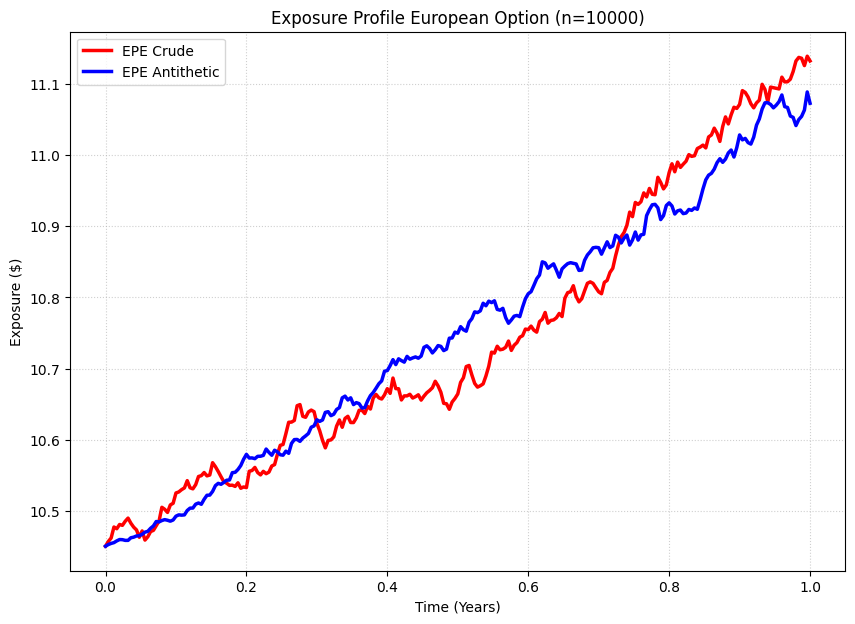

In [9]:
plt.figure(figsize=(10, 7))
plt.plot(time_vector, ee_profile_euro, label="EPE Crude", color="red", linewidth=2.5)
plt.plot(time_vector, ee_profile_euro_ant, label="EPE Antithetic", color="blue", linewidth=2.5)
plt.title(f"Exposure Profile European Option (n={n_sims})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

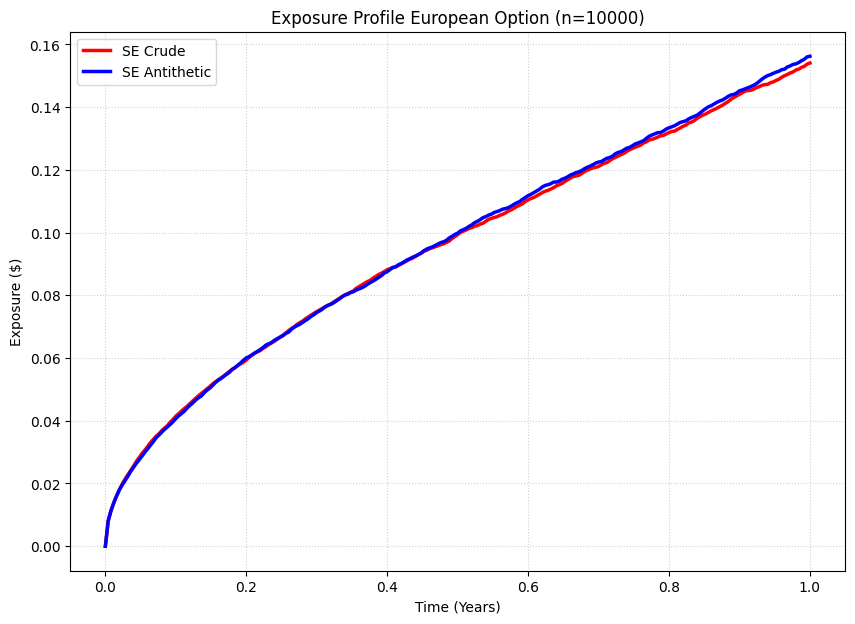

In [10]:
plt.figure(figsize=(10, 7))
plt.plot(time_vector, se_profile_euro, label="SE Crude", color="red", linewidth=2.5)
plt.plot(time_vector, se_profile_euro_ant, label="SE Antithetic", color="blue", linewidth=2.5)
plt.title(f"Exposure Profile European Option (n={n_sims})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

In [11]:
def calculate_mtm_matrix_asian(
    all_paths: np.ndarray,
    k: float,
    r: float,
    sigma: float,
    T_maturity: float,
    omega: int,
    n_sims_inner: int
):
    """
    Calculates the MtM matrix for an Asian option given pre-simulated paths.
    
    This uses a "nested" or "simulation-in-a-simulation" approach.
    """
    
    # 1. Get shape and time info
    n_sims_outer, m_steps_plus_1 = all_paths.shape
    m_steps = m_steps_plus_1 - 1 # m_steps is the m_total_steps for the option
    
    # 2. Create helper variables
    mtm_matrix = np.zeros_like(all_paths)
    time_vector = np.linspace(0, T_maturity, m_steps + 1)
    
    # 3. Loop through TIME (columns)
    for j in range(m_steps + 1): # Loop includes maturity date
        t_current = time_vector[j]
        
        if j % 20 == 0 or j == m_steps:
             print(f"  Pricing time step {j}/{m_steps}...")
        
        # 4. Loop through PATHS (rows)
        for i in range(n_sims_outer):
            
            # Get the state variables for this one node (i, j)
            s_current_i = all_paths[i, j]
            
            # History is S1...Sj (note the slice [:, 1:j+1])
            # At j=0, this is an empty slice, which is correct.
            hist_prices_i = all_paths[i, 1:j+1]
            
            # Call the inner MC pricer
            price_i = price_asian_option_mc(
                s_current=s_current_i,
                k=k, r=r, sigma=sigma,
                T_maturity=T_maturity,
                n_sims=n_sims_inner,
                m_total_steps=m_steps,
                omega=omega,
                t_current=t_current,
                historical_prices=hist_prices_i
            )
            
            mtm_matrix[i, j] = price_i
            
    return mtm_matrix, time_vector

In [ ]:
def calculate_mtm_matrix_asian_antithetic(
    all_paths: np.ndarray,
    k: float,
    r: float,
    sigma: float,
    T_maturity: float,
    omega: int,
    n_sims_inner: int
):
    """
    Calculates the MtM matrix for an Asian option given pre-simulated paths.
    
    Uses a nested loop, but applies ANTITHETIC VARIATES to the 
    inner simulation for variance reduction.
    """
    
    # 1. Get shape and time info
    n_sims_outer, m_steps_plus_1 = all_paths.shape
    m_steps = m_steps_plus_1 - 1 
    
    # 2. Create helper variables
    mtm_matrix = np.zeros_like(all_paths)
    time_vector = np.linspace(0, T_maturity, m_steps + 1)
    
    # For antithetics, we'll run two sims of half the size
    n_half_sims = int(n_sims_inner / 2)
    if n_half_sims * 2 != n_sims_inner:
        print(f"Warning: n_sims_inner ({n_sims_inner}) is odd. Using {n_half_sims*2} sims for antithetics.")
        
    
    print(f"Calculating Asian MtM matrix (Antithetic, {n_sims_outer}x{m_steps+1} points)...")
    
    # 3. Loop through TIME (columns)
    for j in range(m_steps + 1): 
        t_current = time_vector[j]
        
        # Calculate remaining steps for the inner sim
        m_known_steps = j 
        m_remaining_steps = m_steps - m_known_steps
        
        if j % 20 == 0 or j == m_steps:
             print(f"  Pricing time step {j}/{m_steps}...")
        
        
        
        # 4. Loop through PATHS (rows)
        for i in range(n_sims_outer):
            s_current_i = all_paths[i, j]
            hist_prices_i = all_paths[i, 1:j+1]
            
            Z_inner = None
            if m_remaining_steps > 0:
                Z_inner = np.random.normal(0.0, 1.0, (n_half_sims, m_remaining_steps))
            # Z_inner will be None at maturity (j=m_steps)
            if Z_inner is None:
                # At maturity, no sim is needed.
                # Just call the pricer once to get the deterministic payoff.
                price_i = price_asian_option_mc(
                    s_current=s_current_i,
                    k=k, r=r, sigma=sigma,
                    T_maturity=T_maturity,
                    n_sims=n_half_sims,
                    m_total_steps=m_steps,
                    omega=omega,
                    t_current=t_current,
                    historical_prices=hist_prices_i,
                    Z_matrix=None
                )
                mtm_matrix[i, j] = price_i
            else:
                # Before maturity, run the antithetic sims
                price_a = price_asian_option_mc(
                    s_current=s_current_i, k=k, r=r, sigma=sigma,
                    T_maturity=T_maturity, n_sims=n_half_sims,
                    m_total_steps=m_steps, omega=omega,
                    t_current=t_current, historical_prices=hist_prices_i,
                    Z_matrix=Z_inner # Pass in the +Z matrix
                )
                
                price_b = price_asian_option_mc(
                    s_current=s_current_i, k=k, r=r, sigma=sigma,
                    T_maturity=T_maturity, n_sims=n_half_sims,
                    m_total_steps=m_steps, omega=omega,
                    t_current=t_current, historical_prices=hist_prices_i,
                    Z_matrix=-Z_inner # Pass in the -Z matrix
                )
                
                mtm_matrix[i, j] = (price_a + price_b) / 2.0

            
    print(f"Asian (Antithetic) MtM calculation complete.")
    return mtm_matrix, time_vector

In [13]:
s_start = 100
k = 100
r = 0.05
sigma = 0.2
T_maturity = 1.0
n_sims_outer = 10000  
m_steps = 250         
n_sims_inner = 100   
omega = 1            # 1 for a Call option
position = 1         # 1 for LONG

In [14]:

print("Asian Crude")
start_time = time.time()
mtm_matrix_asian, _ = calculate_mtm_matrix_asian(
    all_paths=all_paths, k=k, r=r, sigma=sigma,
    T_maturity=T_maturity, omega=omega, n_sims_inner=n_sims_inner
)
end_time = time.time()
print(f"Simulation complete. Took {end_time - start_time:.4f} seconds.")

Asian Crude
  Pricing time step 0/250...
  Pricing time step 20/250...
  Pricing time step 40/250...
  Pricing time step 60/250...
  Pricing time step 80/250...
  Pricing time step 100/250...
  Pricing time step 120/250...
  Pricing time step 140/250...
  Pricing time step 160/250...
  Pricing time step 180/250...
  Pricing time step 200/250...
  Pricing time step 220/250...
  Pricing time step 240/250...
  Pricing time step 250/250...
Simulation complete. Took 895.6739 seconds.


In [15]:

print("Asian Antithetic")
start_time = time.time()
mtm_matrix_asian_antithetic, time_vector = calculate_mtm_matrix_asian_antithetic(
    all_paths=all_paths_antithetic, k=k, r=r, sigma=sigma,
    T_maturity=T_maturity, omega=omega, n_sims_inner=n_sims_inner
)
end_time = time.time()
print(f"Simulation complete. Took {end_time - start_time:.4f} seconds.")

Asian Antithetic
Calculating Asian MtM matrix (Antithetic, 10000x251 points)...
  Pricing time step 0/250...
  Pricing time step 20/250...
  Pricing time step 40/250...
  Pricing time step 60/250...
  Pricing time step 80/250...
  Pricing time step 100/250...
  Pricing time step 120/250...
  Pricing time step 140/250...
  Pricing time step 160/250...
  Pricing time step 180/250...
  Pricing time step 200/250...
  Pricing time step 220/250...
  Pricing time step 240/250...
  Pricing time step 250/250...
Asian (Antithetic) MtM calculation complete.
Simulation complete. Took 798.3476 seconds.


In [16]:
mtm_asian = mtm_matrix_asian * position
x_asian = np.maximum(mtm_asian, 0)
ee_profile_asian = np.mean(x_asian, axis=0)
se_profile_asian = x_asian.std(axis=0, ddof=1) / np.sqrt(max(n_sims_outer, 1))
pfe_profile_asian = np.quantile(np.maximum(mtm_asian, 0), 0.95, axis=0)

In [20]:
mtm_asian_ant = mtm_matrix_asian_antithetic * position
x_asian_ant = np.maximum(mtm_asian_ant, 0)
ee_profile_asian_ant = np.mean(x_asian_ant, axis=0)
se_profile_asian_ant = x_asian_ant.std(axis=0, ddof=1) / np.sqrt(max(n_sims_outer, 1))
pfe_profile_asian_ant = np.quantile(np.maximum(mtm_asian_ant, 0), 0.95, axis=0)

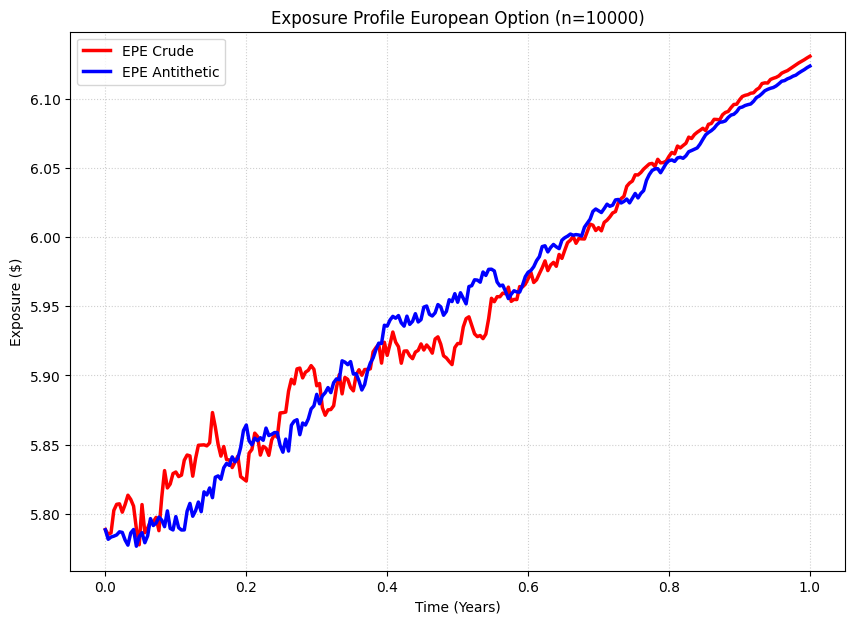

In [21]:
plt.figure(figsize=(10, 7))
plt.plot(time_vector, ee_profile_asian, label="EPE Crude", color="red", linewidth=2.5)
plt.plot(time_vector, ee_profile_asian_ant, label="EPE Antithetic", color="blue", linewidth=2.5)
plt.title(f"Exposure Profile European Option (n={n_sims})")
plt.xlabel("Time (Years)")
plt.ylabel("Exposure ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

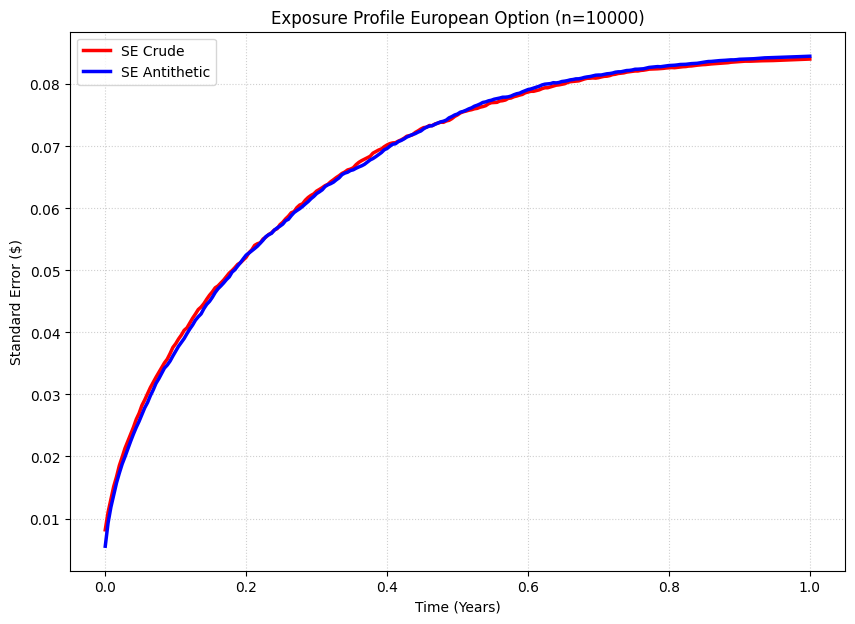

In [22]:
plt.figure(figsize=(10, 7))
plt.plot(time_vector, se_profile_asian, label="SE Crude", color="red", linewidth=2.5)
plt.plot(time_vector, se_profile_asian_ant, label="SE Antithetic", color="blue", linewidth=2.5)
plt.title(f"Exposure Profile European Option (n={n_sims})")
plt.xlabel("Time (Years)")
plt.ylabel("Standard Error ($)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)